In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/content/booktok_germany_master_2023_2026_enriched_clean.xlsx"

rankings = pd.read_excel(file_path, sheet_name="Rankings_Master")
titles = pd.read_excel(file_path, sheet_name="Title_Summary_Master")

print("Ranking rows:", len(rankings))
print("Unique titles:", len(titles))

titles.head()

Ranking rows: 787
Unique titles: 292


,canonical_title,author,months_in_chart,best_rank,avg_rank,first_month_key,last_month_key,repeat_success,years_active,genre,publisher,publication_date_de,isbn_13,series_status,series_number,self_published,metadata_status
0,Just for the Summer,Abby Jimenez,3,10.0,15.333333,202505.0,202508.0,Yes,1.0,Romance / Contemporary,dtv,2025-05-15,978-3-423-26428-0,No,NaN,No,Full verified
1,The Games Gods Play - Schattenverführt,Abigail Owen,1,11.0,11.000000,202410.0,202410.0,No,1.0,Fantasy / Romantasy,dtv,2024-10-17,978-3-423-28428-8,Yes,1.0,No,Full verified
2,Belladonna - Die Berührung des Todes,Adalyn Grace,1,6.0,6.000000,202401.0,202401.0,No,1.0,Fantasy / YA,arsEdition,2024-01-05,978-3-8458-5691-9,Yes,1.0,No,Full verified
3,Wisteria - Die Liebe des Todes,Adalyn Grace,2,10.0,14.500000,202501.0,202502.0,Yes,1.0,Fantasy / YA,arsEdition,2025-01-27,978-3-8458-5706-0,Yes,3.0,No,Full verified
4,Bride - Die unergründliche Übernatürlichkeit d...,Ali Hazelwood,2,4.0,12.000000,202402.0,202404.0,Yes,1.0,Fantasy / Romantasy,Rütten & Loening / Aufbau,2024-02-14,978-3-352-00997-6,No,NaN,No,Full verified


In [2]:
# Keep only complete ranking rows for the core analysis
rankings_core = rankings[
    rankings["main_analysis_include"] == "Yes"
].copy()

print("Rows used for core analysis:", len(rankings_core))

# Define sustained success
titles["sustained_success"] = np.where(
    titles["months_in_chart"] >= 6,
    "Sustained (6+ months)",
    "Shorter-term (<6 months)"
)

titles["sustained_binary"] = np.where(
    titles["months_in_chart"] >= 6,
    1,
    0
)

print()
print(titles["sustained_success"].value_counts())

Rows used for core analysis: 780

sustained_success
Shorter-term (<6 months)    263
Sustained (6+ months)        29
Name: count, dtype: int64


In [3]:
genre_analysis = (
    titles.groupby("genre")
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        sustained_titles=("sustained_binary", "sum")
    )
)

genre_analysis["sustained_rate"] = (
    genre_analysis["sustained_titles"] /
    genre_analysis["total_titles"]
)

genre_analysis = genre_analysis.sort_values(
    "total_titles",
    ascending=False
)

genre_analysis.head(15)

,total_titles,avg_months,median_months,sustained_titles,sustained_rate
genre,,,,,
Romance / New Adult,87,2.103448,1.0,7,0.080460
Fantasy / Romantasy,56,2.160714,1.0,2,0.035714
Dark Romance,28,2.178571,1.0,3,0.107143
Romance / Contemporary,28,2.821429,1.0,2,0.071429
Fantasy / YA,9,1.333333,1.0,0,0.000000
Contemporary Fiction,9,6.333333,2.0,3,0.333333
Thriller / Suspense,9,4.111111,1.0,2,0.222222
Self-Help / Psychology,9,9.222222,12.0,5,0.555556
Fantasy,6,1.333333,1.0,0,0.000000


In [4]:
series_analysis = (
    titles[titles["series_status"].isin(["Yes", "No"])]
    .groupby("series_status")
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        sustained_titles=("sustained_binary", "sum")
    )
)

series_analysis["sustained_rate"] = (
    series_analysis["sustained_titles"] /
    series_analysis["total_titles"]
)

series_analysis

,total_titles,avg_months,median_months,sustained_titles,sustained_rate
series_status,,,,,
No,80,3.912500,2.0,14,0.175000
Yes,207,2.207729,1.0,15,0.072464


In [5]:
from scipy.stats import fisher_exact

# Create contingency table
contingency = pd.crosstab(
    titles[titles["series_status"].isin(["Yes", "No"])]["series_status"],
    titles[titles["series_status"].isin(["Yes", "No"])]["sustained_binary"]
)

print(contingency)

odds_ratio, p_value = fisher_exact(contingency)

print("Odds ratio:", odds_ratio)
print("p-value:", p_value)

sustained_binary    0   1
series_status            
No                 66  14
Yes               192  15
Odds ratio: 0.36830357142857145
p-value: 0.015131824301978288


In [6]:
# Convert publication date to datetime
titles["publication_date_de"] = pd.to_datetime(
    titles["publication_date_de"],
    errors="coerce"
)

# Convert first_month_key like 202504 into a date
titles["first_chart_date"] = pd.to_datetime(
    titles["first_month_key"].astype("Int64").astype(str),
    format="%Y%m",
    errors="coerce"
)

# Calculate book age in months at first chart appearance
titles["book_age_months"] = (
    (titles["first_chart_date"].dt.year - titles["publication_date_de"].dt.year) * 12
    + (titles["first_chart_date"].dt.month - titles["publication_date_de"].dt.month)
)

# Group titles into publication-age categories
titles["release_age_group"] = pd.cut(
    titles["book_age_months"],
    bins=[-1000, 6, 24, 1000],
    labels=[
        "New release (≤6 months)",
        "Recent (7–24 months)",
        "Backlist (>24 months)"
    ]
)

age_analysis = (
    titles.dropna(subset=["release_age_group"])
    .groupby("release_age_group", observed=False)
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        sustained_titles=("sustained_binary", "sum")
    )
)

age_analysis["sustained_rate"] = (
    age_analysis["sustained_titles"] /
    age_analysis["total_titles"]
)

age_analysis

,total_titles,avg_months,median_months,sustained_titles,sustained_rate
release_age_group,,,,,
New release (≤6 months),236,2.224576,1.0,15,0.063559
Recent (7–24 months),9,2.666667,1.0,1,0.111111
Backlist (>24 months),9,8.888889,4.0,4,0.444444


In [7]:
titles[
    [
        "canonical_title",
        "author",
        "publication_date_de",
        "first_chart_date",
        "book_age_months",
        "release_age_group",
        "months_in_chart"
    ]
].sort_values("book_age_months", ascending=False).head(15)

,canonical_title,author,publication_date_de,first_chart_date,book_age_months,release_age_group,months_in_chart
132,Das Café am Rande der Welt,John Strelecky,2007-02-01,2026-06-01,232.0,Backlist (>24 months),1
133,The Big Five for Life,John Strelecky,2009-02-01,2023-12-01,178.0,Backlist (>24 months),6
251,Power: Die 48 Gesetze der Macht,Robert Greene,2013-01-28,2023-11-01,130.0,Backlist (>24 months),2
273,Das Kind in dir muss Heimat finden,Stefanie Stahl,2015-11-16,2023-05-01,90.0,Backlist (>24 months),19
46,Wie die Ruhe vor dem Sturm,Brittainy Cherry,2020-06-29,2024-12-01,54.0,Backlist (>24 months),3
262,Das Reich der sieben Höfe - Dornen und Rosen,Sarah J. Maas,2020-05-22,2024-03-01,46.0,Backlist (>24 months),4
237,"Das Buch, von dem du dir wünschst, deine Elter...",Philippa Perry,2020-04-14,2023-09-01,41.0,Backlist (>24 months),4
126,"Die 1%-Methode - Minimale Veränderung, maximal...",James Clear,2020-04-27,2023-04-01,36.0,Backlist (>24 months),20
76,Nur noch ein einziges Mal,Colleen Hoover,2020-11-13,2023-04-01,29.0,Backlist (>24 months),21
146,"50 Sätze, die das Leben leichter machen",Karin Kuschik,2022-03-22,2023-10-01,19.0,Recent (7–24 months),1


In [8]:
from scipy.stats import chi2_contingency

age_contingency = pd.crosstab(
    titles["release_age_group"],
    titles["sustained_binary"]
)

print(age_contingency)

chi2, p_value, dof, expected = chi2_contingency(age_contingency)

print("Chi-square:", chi2)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

sustained_binary           0   1
release_age_group               
New release (≤6 months)  221  15
Recent (7–24 months)       8   1
Backlist (>24 months)      5   4
Chi-square: 17.47274655141887
p-value: 0.0001606354131110048
Degrees of freedom: 2


In [9]:
titles["age_binary"] = np.where(
    titles["book_age_months"] <= 6,
    "New release (≤6 months)",
    "Older title (>6 months)"
)

age_binary_table = pd.crosstab(
    titles["age_binary"],
    titles["sustained_binary"]
)

print(age_binary_table)

odds_ratio_age, p_value_age = fisher_exact(age_binary_table)

print("Odds ratio:", odds_ratio_age)
print("p-value:", p_value_age)

sustained_binary           0   1
age_binary                      
New release (≤6 months)  221  15
Older title (>6 months)   42  14
Odds ratio: 4.911111111111111
p-value: 0.00016087749533913164


In [10]:
# Only use titles with known book age
age_known = titles.dropna(subset=["book_age_months"]).copy()

age_known["age_binary"] = np.where(
    age_known["book_age_months"] <= 6,
    "New release (≤6 months)",
    "Older title (>6 months)"
)

age_binary_table = pd.crosstab(
    age_known["age_binary"],
    age_known["sustained_binary"]
)

print(age_binary_table)

odds_ratio_age, p_value_age = fisher_exact(age_binary_table)

print("Odds ratio:", odds_ratio_age)
print("p-value:", p_value_age)

sustained_binary           0   1
age_binary                      
New release (≤6 months)  221  15
Older title (>6 months)   13   5
Odds ratio: 5.666666666666667
p-value: 0.007970361633691251


In [11]:
# Get the first chart appearance for each title
first_entries = (
    rankings_core
    .sort_values(["canonical_title", "author", "month_key"])
    .groupby(["canonical_title", "author"])
    .first()
    .reset_index()
)

# Keep entry rank
first_entries = first_entries[
    ["canonical_title", "author", "booktok_rank"]
].rename(columns={"booktok_rank": "entry_rank"})

# Merge with title-level data
titles = titles.merge(
    first_entries,
    on=["canonical_title", "author"],
    how="left"
)

# Compare entry rank
entry_analysis = (
    titles.groupby("sustained_success")
    .agg(
        total_titles=("canonical_title", "count"),
        avg_entry_rank=("entry_rank", "mean"),
        median_entry_rank=("entry_rank", "median")
    )
)

entry_analysis

,total_titles,avg_entry_rank,median_entry_rank
sustained_success,,,
Shorter-term (<6 months),263,11.065385,11.0
Sustained (6+ months),29,8.931034,7.0


In [12]:
from scipy.stats import mannwhitneyu

sustained_ranks = titles.loc[
    titles["sustained_binary"] == 1,
    "entry_rank"
].dropna()

short_ranks = titles.loc[
    titles["sustained_binary"] == 0,
    "entry_rank"
].dropna()

stat, p_value_entry = mannwhitneyu(
    sustained_ranks,
    short_ranks,
    alternative="two-sided"
)

print("Median entry rank - sustained:", sustained_ranks.median())
print("Median entry rank - shorter-term:", short_ranks.median())
print("p-value:", p_value_entry)

Median entry rank - sustained: 7.0
Median entry rank - shorter-term: 11.0
p-value: 0.07850645643392092


In [15]:
def group_genre(genre):
    if pd.isna(genre):
        return "Other"

    genre = str(genre)

    if genre in [
        "Romance / New Adult",
        "Romance / Contemporary",
        "Sports Romance / New Adult",
        "YA Romance"
    ]:
        return "New Adult / Contemporary Romance"

    elif genre in [
        "Dark Romance",
        "Thriller / Dark Romance"
    ]:
        return "Dark Romance"

    elif genre in [
        "Fantasy / Romantasy",
        "Fantasy / YA",
        "Fantasy",
        "YA Fantasy / Dystopian"
    ]:
        return "Fantasy / Romantasy"

    elif genre in [
        "Thriller / Suspense",
        "YA Thriller / Mystery"
    ]:
        return "Thriller / Mystery"

    elif genre in [
        "Contemporary Fiction",
        "Historical / Contemporary Fiction",
        "Contemporary / Speculative"
    ]:
        return "Contemporary / Literary Fiction"

    elif genre in [
        "Self-Help / Psychology",
        "Self-Help / Business",
        "Memoir / Social Commentary"
    ]:
        return "Self-Help / Non-Fiction"

    else:
        return "Other"


titles["genre_group"] = titles["genre"].apply(group_genre)

titles["genre_group"].value_counts()

,count
genre_group,
New Adult / Contemporary Romance,120
Fantasy / Romantasy,75
Other,31
Dark Romance,30
Contemporary / Literary Fiction,14
Self-Help / Non-Fiction,12
Thriller / Mystery,10


In [16]:
titles.loc[
    titles["genre_group"] == "Other",
    ["genre", "canonical_title", "author"]
].sort_values("genre")

,genre,canonical_title,author
32,Contemporary / Coming-of-Age,Hard Land,Benedict Wells
231,Contemporary / Romance,Abendlicht,Nora Roberts
216,Contemporary / Speculative Fiction,Die Mitternachtsreise,Matt Haig
287,Contemporary Fiction / Art,Monas Augen - Eine Reise zu den schönsten Kuns...,Thomas Schlesser
274,Cooking / Nonfiction,"Hensslers Schnelle Nummer – morgens, mittags, ...",Steffen Henssler
106,Dark Romance / Horror,Satan’s Affair,H. D. Carlton
227,Dark Romance / RomCom,Rush In,Navessa Allen
226,Dark Romance / Romcom,Lights Out,Navessa Allen
128,Dark Romance / Thriller,Still Beating,Jennifer Hartmann
286,Fantasy / Children's & YA,Alea Aquarius 10. Der Stern des Schicksals,Tanya Stewner


In [17]:
def group_genre(genre):
    if pd.isna(genre):
        return "Other"

    g = str(genre).lower()

    # Dark Romance first so it doesn't get absorbed into general romance
    if "dark romance" in g:
        return "Dark Romance"

    # Romance
    elif (
        "romance" in g
        or "new adult" in g
        or "sports romance" in g
    ) and "fantasy" not in g:
        return "New Adult / Contemporary Romance"

    # Fantasy / Romantasy
    elif (
        "fantasy" in g
        or "romantasy" in g
        or "dystopian" in g
    ):
        return "Fantasy / Romantasy"

    # Thriller / Mystery
    elif (
        "thriller" in g
        or "mystery" in g
        or "crime" in g
    ):
        return "Thriller / Mystery"

    # Self-help and broad non-fiction
    elif (
        "self-help" in g
        or "psychology" in g
        or "memoir" in g
        or "nonfiction" in g
        or "non-fiction" in g
        or "social commentary" in g
        or "spirituality" in g
        or "business" in g
    ):
        return "Self-Help / Non-Fiction"

    # Contemporary / literary fiction
    elif (
        "contemporary" in g
        or "literary" in g
        or "coming-of-age" in g
        or "speculative fiction" in g
    ):
        return "Contemporary / Literary Fiction"

    else:
        return "Other"


titles["genre_group"] = titles["genre"].apply(group_genre)

titles["genre_group"].value_counts()

,count
genre_group,
New Adult / Contemporary Romance,127
Fantasy / Romantasy,80
Dark Romance,34
Self-Help / Non-Fiction,20
Contemporary / Literary Fiction,18
Thriller / Mystery,12
Other,1


In [18]:
titles.loc[
    titles["genre_group"] == "Other",
    ["genre", "canonical_title", "author"]
].sort_values("genre")

,genre,canonical_title,author
9,YA Graphic Novel / LGBTQ+,Heartstopper Volume 6,Alice Oseman


In [19]:
genre_group_analysis = (
    titles.groupby("genre_group")
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        sustained_titles=("sustained_binary", "sum")
    )
)

genre_group_analysis["sustained_rate"] = (
    genre_group_analysis["sustained_titles"] /
    genre_group_analysis["total_titles"]
)

genre_group_analysis = genre_group_analysis.sort_values(
    "sustained_rate",
    ascending=False
)

genre_group_analysis

,total_titles,avg_months,median_months,sustained_titles,sustained_rate
genre_group,,,,,
Self-Help / Non-Fiction,20,5.800000,2.5,7,0.350000
Thriller / Mystery,12,4.083333,1.5,3,0.250000
Contemporary / Literary Fiction,18,5.333333,2.5,4,0.222222
Dark Romance,34,2.147059,1.0,3,0.088235
New Adult / Contemporary Romance,127,2.259843,1.0,9,0.070866
Fantasy / Romantasy,80,1.975000,1.0,3,0.037500
Other,1,1.000000,1.0,0,0.000000


In [20]:
from scipy.stats import chi2_contingency

genre_contingency = pd.crosstab(
    titles["genre_group"],
    titles["sustained_binary"]
)

print(genre_contingency)

chi2_genre, p_genre, dof_genre, expected_genre = chi2_contingency(
    genre_contingency
)

print("Chi-square:", chi2_genre)
print("p-value:", p_genre)
print("Degrees of freedom:", dof_genre)

sustained_binary                    0  1
genre_group                             
Contemporary / Literary Fiction    14  4
Dark Romance                       31  3
Fantasy / Romantasy                77  3
New Adult / Contemporary Romance  118  9
Other                               1  0
Self-Help / Non-Fiction            13  7
Thriller / Mystery                  9  3
Chi-square: 24.85985065597432
p-value: 0.0003624686596574724
Degrees of freedom: 6


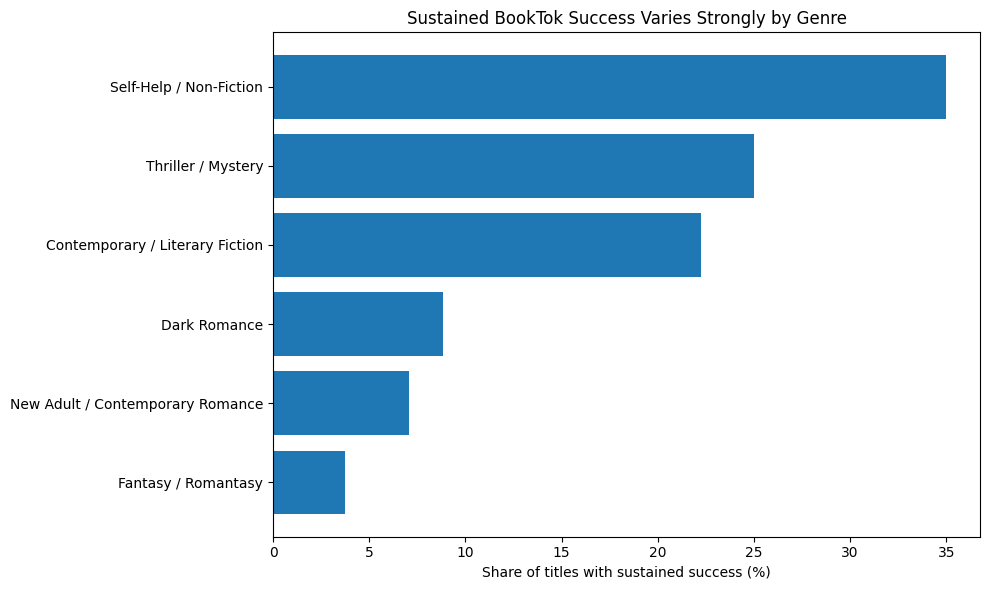

In [21]:
plot_data = (
    genre_group_analysis
    .drop(index="Other", errors="ignore")
    .sort_values("sustained_rate")
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data.index,
    plot_data["sustained_rate"] * 100
)

plt.xlabel("Share of titles with sustained success (%)")
plt.ylabel("")
plt.title("Sustained BookTok Success Varies Strongly by Genre")

plt.tight_layout()
plt.show()

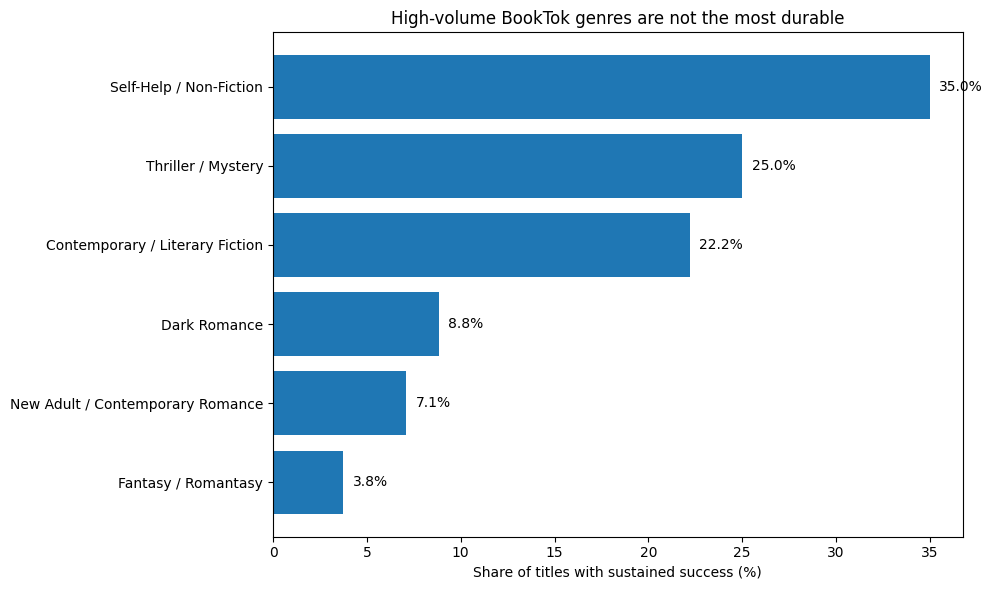

In [22]:
plot_data = (
    genre_group_analysis
    .drop(index="Other", errors="ignore")
    .sort_values("sustained_rate")
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data.index,
    plot_data["sustained_rate"] * 100
)

plt.xlabel("Share of titles with sustained success (%)")
plt.ylabel("")
plt.title("High-volume BookTok genres are not the most durable")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

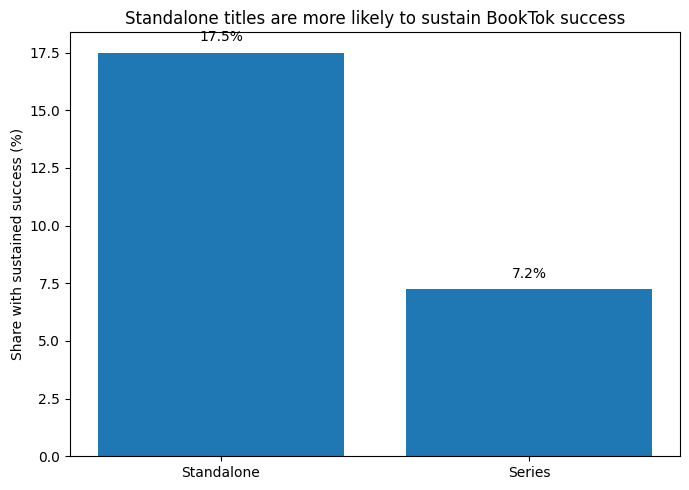

In [23]:
series_plot = series_analysis.copy()

# Rename for clearer presentation labels
series_plot.index = series_plot.index.map({
    "No": "Standalone",
    "Yes": "Series"
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    series_plot.index,
    series_plot["sustained_rate"] * 100
)

plt.ylabel("Share with sustained success (%)")
plt.title("Standalone titles are more likely to sustain BookTok success")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

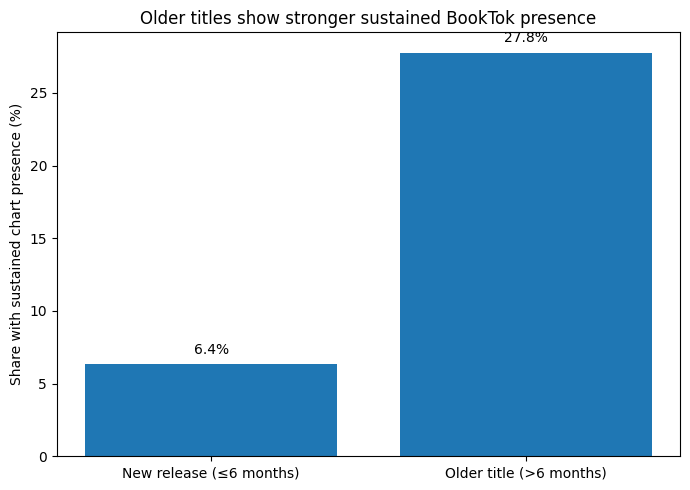

In [24]:
age_plot = pd.DataFrame({
    "Group": [
        "New release (≤6 months)",
        "Older title (>6 months)"
    ],
    "Sustained rate": [
        15 / 236,
        5 / 18
    ]
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    age_plot["Group"],
    age_plot["Sustained rate"] * 100
)

plt.ylabel("Share with sustained chart presence (%)")
plt.title("Older titles show stronger sustained BookTok presence")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.7,
        f"{height:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [25]:
# Compare actual months in chart by series status
series_months = (
    titles[titles["series_status"].isin(["Yes", "No"])]
    .groupby("series_status")["months_in_chart"]
    .agg(["count", "mean", "median"])
)

series_months

,count,mean,median
series_status,,,
No,80,3.912500,2.0
Yes,207,2.207729,1.0


In [26]:
from scipy.stats import mannwhitneyu

series_yes = titles.loc[
    titles["series_status"] == "Yes",
    "months_in_chart"
].dropna()

series_no = titles.loc[
    titles["series_status"] == "No",
    "months_in_chart"
].dropna()

stat, p_series_months = mannwhitneyu(
    series_yes,
    series_no,
    alternative="two-sided"
)

print("Median months - series:", series_yes.median())
print("Median months - standalone:", series_no.median())
print("p-value:", p_series_months)

Median months - series: 1.0
Median months - standalone: 2.0
p-value: 0.0015813294637205886


In [27]:
# Use only titles with known publication age
age_known = titles.dropna(subset=["book_age_months"]).copy()

new_release_months = age_known.loc[
    age_known["book_age_months"] <= 6,
    "months_in_chart"
]

older_title_months = age_known.loc[
    age_known["book_age_months"] > 6,
    "months_in_chart"
]

print("New releases:")
print("Count:", len(new_release_months))
print("Mean months:", new_release_months.mean())
print("Median months:", new_release_months.median())

print()

print("Older titles:")
print("Count:", len(older_title_months))
print("Mean months:", older_title_months.mean())
print("Median months:", older_title_months.median())

New releases:
Count: 236
Mean months: 2.2245762711864407
Median months: 1.0

Older titles:
Count: 18
Mean months: 5.777777777777778
Median months: 3.0


In [28]:
from scipy.stats import mannwhitneyu

stat, p_age_months = mannwhitneyu(
    new_release_months,
    older_title_months,
    alternative="two-sided"
)

print("p-value:", p_age_months)

p-value: 0.00768716949762781


In [29]:
publisher_analysis = (
    titles.dropna(subset=["publisher"])
    .groupby("publisher")
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        sustained_titles=("sustained_binary", "sum")
    )
)

publisher_analysis["sustained_rate"] = (
    publisher_analysis["sustained_titles"] /
    publisher_analysis["total_titles"]
)

publisher_analysis = publisher_analysis.sort_values(
    "total_titles",
    ascending=False
)

publisher_analysis.head(20)

,total_titles,avg_months,median_months,sustained_titles,sustained_rate
publisher,,,,,
LYX,43,2.441860,2.0,4,0.093023
dtv,22,5.545455,1.5,6,0.272727
Penguin,20,2.100000,1.0,1,0.050000
Goldmann,13,4.153846,2.0,2,0.153846
Heyne,12,1.750000,1.0,1,0.083333
everlove / Piper,12,2.583333,2.0,1,0.083333
Carlsen,10,1.200000,1.0,0,0.000000
Blanvalet,10,1.900000,1.0,1,0.100000
VAJONA,10,2.000000,1.0,1,0.100000


In [30]:
publisher_durability = (
    publisher_analysis[
        publisher_analysis["total_titles"] >= 5
    ]
    .sort_values("sustained_rate", ascending=False)
)

publisher_durability

,total_titles,avg_months,median_months,sustained_titles,sustained_rate
publisher,,,,,
cbt,7,3.714286,2.0,2,0.285714
dtv,22,5.545455,1.5,6,0.272727
Blush Blanvalet,6,2.333333,1.5,1,0.166667
Goldmann,13,4.153846,2.0,2,0.153846
Blanvalet,10,1.900000,1.0,1,0.100000
VAJONA,10,2.000000,1.0,1,0.100000
LYX,43,2.441860,2.0,4,0.093023
everlove / Piper,12,2.583333,2.0,1,0.083333
Heyne,12,1.750000,1.0,1,0.083333


In [31]:
publisher_genre = (
    titles.dropna(subset=["publisher", "genre_group"])
    .groupby(["genre_group", "publisher"])
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        sustained_titles=("sustained_binary", "sum")
    )
    .reset_index()
)

publisher_genre["sustained_rate"] = (
    publisher_genre["sustained_titles"] /
    publisher_genre["total_titles"]
)

# keep publishers with at least 3 titles in that genre
publisher_genre_filtered = publisher_genre[
    publisher_genre["total_titles"] >= 3
].copy()

publisher_genre_filtered.head(20)

,genre_group,publisher,total_titles,avg_months,median_months,sustained_titles,sustained_rate
6,Contemporary / Literary Fiction,Goldmann,4,2.250000,2.0,0,0.000000
14,Dark Romance,Blush Blanvalet,5,2.600000,2.0,1,0.200000
19,Dark Romance,VAJONA,10,2.000000,1.0,1,0.100000
21,Dark Romance,WondaVersum / Nova MD,5,1.400000,1.0,0,0.000000
22,Dark Romance,everlove / Piper,6,3.166667,2.0,1,0.166667
26,Fantasy / Romantasy,Carlsen,7,1.285714,1.0,0,0.000000
29,Fantasy / Romantasy,FISCHER,3,2.333333,2.0,0,0.000000
30,Fantasy / Romantasy,Forever / Ullstein,3,2.333333,1.0,0,0.000000
31,Fantasy / Romantasy,Goldmann,3,2.000000,2.0,0,0.000000
34,Fantasy / Romantasy,KYSS / Rowohlt,4,1.250000,1.0,0,0.000000


In [32]:
publisher_genre_filtered["rank_in_genre"] = (
    publisher_genre_filtered
    .groupby("genre_group")["sustained_rate"]
    .rank(method="dense", ascending=False)
)

publisher_genre_ranked = publisher_genre_filtered.sort_values(
    ["genre_group", "rank_in_genre", "avg_months"],
    ascending=[True, True, False]
)

publisher_genre_ranked

,genre_group,publisher,total_titles,avg_months,median_months,sustained_titles,sustained_rate,rank_in_genre
6,Contemporary / Literary Fiction,Goldmann,4,2.250000,2.0,0,0.000000,1.0
14,Dark Romance,Blush Blanvalet,5,2.600000,2.0,1,0.200000,1.0
22,Dark Romance,everlove / Piper,6,3.166667,2.0,1,0.166667,2.0
19,Dark Romance,VAJONA,10,2.000000,1.0,1,0.100000,3.0
21,Dark Romance,WondaVersum / Nova MD,5,1.400000,1.0,0,0.000000,4.0
52,Fantasy / Romantasy,dtv,10,4.700000,1.0,2,0.200000,1.0
44,Fantasy / Romantasy,Penhaligon,5,2.600000,2.0,0,0.000000,2.0
29,Fantasy / Romantasy,FISCHER,3,2.333333,2.0,0,0.000000,2.0
30,Fantasy / Romantasy,Forever / Ullstein,3,2.333333,1.0,0,0.000000,2.0
31,Fantasy / Romantasy,Goldmann,3,2.000000,2.0,0,0.000000,2.0


In [33]:
publisher_genre_presence = (
    titles.dropna(subset=["publisher", "genre_group"])
    .groupby(["genre_group", "publisher"])
    .agg(
        number_of_titles=("canonical_title", "nunique")
    )
    .reset_index()
)

publisher_genre_presence["rank_in_genre"] = (
    publisher_genre_presence
    .groupby("genre_group")["number_of_titles"]
    .rank(method="dense", ascending=False)
)

publisher_genre_presence = publisher_genre_presence.sort_values(
    ["genre_group", "rank_in_genre", "publisher"]
)

publisher_genre_presence

,genre_group,publisher,number_of_titles,rank_in_genre
6,Contemporary / Literary Fiction,Goldmann,4,1.0
0,Contemporary / Literary Fiction,Blanvalet,2,2.0
4,Contemporary / Literary Fiction,DuMont Buchverlag,2,2.0
9,Contemporary / Literary Fiction,Penguin,2,2.0
1,Contemporary / Literary Fiction,Diogenes Verlag AG,1,3.0
...,...,...,...,...
98,Thriller / Mystery,ONE,1,2.0
100,Thriller / Mystery,Penguin Books UK,1,2.0
101,Thriller / Mystery,Piper,1,2.0
102,Thriller / Mystery,cbt,1,2.0


In [34]:
top5_publishers_by_genre = (
    publisher_genre_presence[
        publisher_genre_presence["rank_in_genre"] <= 5
    ]
)

top5_publishers_by_genre

,genre_group,publisher,number_of_titles,rank_in_genre
6,Contemporary / Literary Fiction,Goldmann,4,1.0
0,Contemporary / Literary Fiction,Blanvalet,2,2.0
4,Contemporary / Literary Fiction,DuMont Buchverlag,2,2.0
9,Contemporary / Literary Fiction,Penguin,2,2.0
1,Contemporary / Literary Fiction,Diogenes Verlag AG,1,3.0
...,...,...,...,...
98,Thriller / Mystery,ONE,1,2.0
100,Thriller / Mystery,Penguin Books UK,1,2.0
101,Thriller / Mystery,Piper,1,2.0
102,Thriller / Mystery,cbt,1,2.0


In [35]:
number_one_publishers = (
    publisher_genre_presence[
        publisher_genre_presence["rank_in_genre"] == 1
    ]
)

number_one_publishers

,genre_group,publisher,number_of_titles,rank_in_genre
6,Contemporary / Literary Fiction,Goldmann,4,1.0
19,Dark Romance,VAJONA,10,1.0
52,Fantasy / Romantasy,dtv,10,1.0
65,New Adult / Contemporary Romance,LYX,38,1.0
79,Other,Loewe,1,1.0
95,Self-Help / Non-Fiction,dtv,3,1.0
96,Thriller / Mystery,Heyne,3,1.0
99,Thriller / Mystery,Penguin,3,1.0


In [36]:
top10_publishers = (
    titles.dropna(subset=["publisher"])
    .groupby("publisher")
    .agg(
        number_of_titles=("canonical_title", "nunique")
    )
    .sort_values("number_of_titles", ascending=False)
    .head(10)
)

top10_publishers

,number_of_titles
publisher,
LYX,43
dtv,22
Penguin,20
Goldmann,13
Heyne,12
everlove / Piper,12
Carlsen,10
Blanvalet,10
VAJONA,10


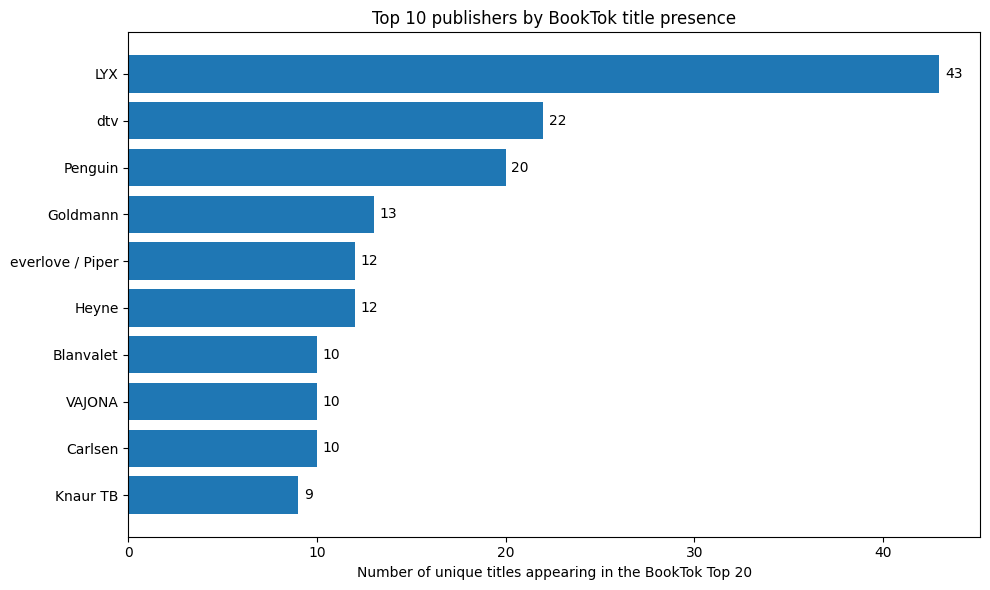

In [37]:
plot_data = top10_publishers.sort_values(
    "number_of_titles",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    plot_data.index,
    plot_data["number_of_titles"]
)

plt.xlabel("Number of unique titles appearing in the BookTok Top 20")
plt.ylabel("")
plt.title("Top 10 publishers by BookTok title presence")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [38]:
selfpub_summary = (
    titles[titles["self_published"].isin(["Yes", "No"])]
    .groupby("self_published")
    .agg(
        number_of_titles=("canonical_title", "nunique"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median")
    )
)

selfpub_summary

,number_of_titles,avg_months,median_months
self_published,,,
No,266,2.56391,1.0
Yes,12,1.50000,1.0


In [39]:
selfpub_share = (
    titles[titles["self_published"].isin(["Yes", "No"])]
    ["self_published"]
    .value_counts()
    .to_frame("number_of_titles")
)

selfpub_share["share_percent"] = (
    selfpub_share["number_of_titles"]
    / selfpub_share["number_of_titles"].sum()
    * 100
)

selfpub_share

,number_of_titles,share_percent
self_published,,
No,266,95.683453
Yes,12,4.316547


In [40]:
rankings_with_selfpub = rankings_core.merge(
    titles[["canonical_title", "author", "self_published"]],
    on=["canonical_title", "author"],
    how="left"
)

selfpub_appearances = (
    rankings_with_selfpub[
        rankings_with_selfpub["self_published"].isin(["Yes", "No"])
    ]
    ["self_published"]
    .value_counts()
    .to_frame("chart_appearances")
)

selfpub_appearances["share_percent"] = (
    selfpub_appearances["chart_appearances"]
    / selfpub_appearances["chart_appearances"].sum()
    * 100
)

selfpub_appearances

,chart_appearances,share_percent
self_published,,
No,682,97.428571
Yes,18,2.571429


In [41]:
genre_performance = (
    titles.groupby("genre_group")
    .agg(
        total_titles=("canonical_title", "count"),
        avg_months=("months_in_chart", "mean"),
        median_months=("months_in_chart", "median"),
        avg_best_rank=("best_rank", "mean"),
        avg_rank=("avg_rank", "mean")
    )
    .sort_values("avg_months", ascending=False)
)

genre_performance

,total_titles,avg_months,median_months,avg_best_rank,avg_rank
genre_group,,,,,
Self-Help / Non-Fiction,20,5.800000,2.5,10.500000,13.552918
Contemporary / Literary Fiction,18,5.333333,2.5,10.833333,13.384091
Thriller / Mystery,12,4.083333,1.5,9.083333,11.780423
New Adult / Contemporary Romance,127,2.259843,1.0,10.158730,11.785179
Dark Romance,34,2.147059,1.0,8.727273,10.527357
Fantasy / Romantasy,80,1.975000,1.0,8.949367,10.395196
Other,1,1.000000,1.0,1.000000,1.000000
